In [1]:
!pip install --upgrade typing_extensions

In [1]:
FAST_MODE = True  # Set to False when you want full training.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
# from imblearn.over_sampling import SMOTE
import kagglehub


In [ ]:
# path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
# df = pd.read_csv(f"{path}/fake_job_postings.csv")

df = pd.read_csv(f"fake_job_postings_augmented.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Fraud rate: {df['fraudulent'].mean()*100:.2f}%")


Dataset loaded: (29880, 18)
Fraud rate: 43.06%


# Combine, Clean text

In [4]:
def combine_text_fields(row):
    """Combine all text fields"""
    fields = [
        'title', 'location', 'company_profile', 'description',
        'requirements', 'benefits', 'required_experience',
        'required_education', 'industry', 'function'
    ]

    text_parts = []
    for field in fields:
        if pd.notna(row[field]):
            text_parts.append(str(row[field]))

    return ' '.join(text_parts) if text_parts else "unknown job"


def clean_text(text):
    """Clean text (38832 style)"""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()


print("Combining and cleaning text...")
df['combined_text'] = df.apply(combine_text_fields, axis=1)
df['text_cleaned'] = df['combined_text'].apply(clean_text)
print("Done")


Combining and cleaning text...
Done


# Tokenize and Pad

In [ ]:
print("Tokenizing text...")
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# y = df['fraudulent'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text_cleaned'], df['fraudulent'].values,
    test_size=0.30,
    random_state=42,
    stratify=df['fraudulent'].values
)

tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

MAX_SEQUENCE_LENGTH = 256 if FAST_MODE else 500

X_train = pad_sequences(X_train_seq,maxlen=MAX_SEQUENCE_LENGTH,padding='post',truncating='post')
X_test = pad_sequences(X_test_seq,maxlen=MAX_SEQUENCE_LENGTH,padding='post',truncating='post')

print("Done")
print(f"  Train Sequence shape: {X_train.shape}")
print(f"  Test Sequence shape: {X_test.shape}")

print(f"  Vocabulary size: {len(tokenizer.word_index)}")


Tokenizing text...
Done
  Train Sequence shape: (20916, 256)
  Test Sequence shape: (8964, 256)
  Vocabulary size: 151392


# Stratified split

In [16]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X_padded, y,
#     test_size=0.30,
#     random_state=42,
#     stratify=y
# )

# print(f"Train/Test Split (Stratified):")
# print(f"  Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.2f}%")
# print(f"  Test:  {X_test.shape}, fraud rate: {y_test.mean()*100:.2f}%")


# Class weights

In [ ]:
# print("Calculating class weights instead of SMOTE...")

# from sklearn.utils.class_weight import compute_class_weight

# class_weights = compute_class_weight(
#     'balanced',
#     classes=np.unique(y_train),
#     y=y_train
# )

# class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
# print(f"Class weights: {class_weight_dict}")

# X_train_final = X_train
# y_train_final = y_train


# LSTM model

In [ ]:
print("\nBuilding LSTM model...")

EMBEDDING_DIM = 64 if FAST_MODE else 128
LSTM_UNITS = 64 if FAST_MODE else 128
DENSE_UNITS = 32 if FAST_MODE else 64

model = Sequential([
    Embedding(input_dim=10000,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LENGTH),
    LSTM(LSTM_UNITS),
    Dropout(0.3),
    Dense(DENSE_UNITS, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print(model.summary())


Building LSTM model...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 256, 64)           640000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 675,137
Trainable params: 675,137
Non-trainable params: 0
_________________________________________________________________
None


In [ ]:
print("\nTraining LSTM...")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("✓ Training complete\n")


Training LSTM...
Epoch 1/10
523/523 [==============================] - 38s 68ms/step - loss: 0.3816 - accuracy: 0.8465 - val_loss: 0.3022 - val_accuracy: 0.9003
Epoch 2/10
523/523 [==============================] - 35s 66ms/step - loss: 0.2826 - accuracy: 0.8923 - val_loss: 0.1151 - val_accuracy: 0.9696
Epoch 3/10
523/523 [==============================] - 35s 67ms/step - loss: 0.1141 - accuracy: 0.9708 - val_loss: 0.2537 - val_accuracy: 0.9479
Epoch 4/10
523/523 [==============================] - 35s 67ms/step - loss: 0.1386 - accuracy: 0.9564 - val_loss: 0.0954 - val_accuracy: 0.9735
Epoch 5/10
523/523 [==============================] - 35s 67ms/step - loss: 0.0878 - accuracy: 0.9770 - val_loss: 0.0953 - val_accuracy: 0.9773
Epoch 6/10
523/523 [==============================] - 35s 66ms/step - loss: 0.0679 - accuracy: 0.9815 - val_loss: 0.0873 - val_accuracy: 0.9780
Epoch 7/10
523/523 [==============================] - 35s 67ms/step - loss: 0.0547 - accuracy: 0.9845 - val_loss: 0.08

In [8]:
print("\n" + "="*80)
print("LSTM MODEL RESULTS")
print("="*80)

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.4).astype(int).flatten()

print("="*80)
print("LSTM RESULTS")
print("="*80)
accuracy_lstm = accuracy_score(y_test, y_pred)
f1_lstm = f1_score(y_test, y_pred)
precision_lstm = precision_score(y_test, y_pred)
recall_lstm = recall_score(y_test, y_pred)
roc_auc_lstm = roc_auc_score(y_test, y_pred_proba)


print(f"Accuracy:  {accuracy_lstm:.4f}")
print(f"F1-Score:  {f1_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall:    {recall_lstm:.4f}")
print(f"ROC-AUC:   {roc_auc_lstm:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


LSTM MODEL RESULTS
LSTM RESULTS
Accuracy:  0.9807
F1-Score:  0.9772
Precision: 0.9949
Recall:    0.9601
ROC-AUC:   0.9930

Confusion Matrix:
[[5085   19]
 [ 154 3706]]


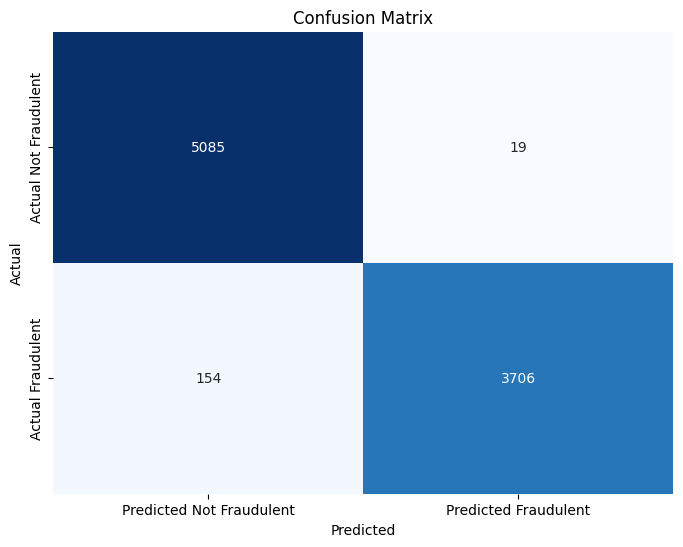

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Fraudulent', 'Predicted Fraudulent'],
            yticklabels=['Actual Not Fraudulent', 'Actual Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
print("\n" + "="*80)
print("THRESHOLD OPTIMIZATION")
print("="*80)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"Threshold {thresh}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n✓ Best threshold: {best_threshold} (F1={best_f1:.4f})")


THRESHOLD OPTIMIZATION
Threshold 0.3: Acc=0.9809, Prec=0.9946, Rec=0.9609, F1=0.9775
Threshold 0.4: Acc=0.9807, Prec=0.9949, Rec=0.9601, F1=0.9772
Threshold 0.5: Acc=0.9807, Prec=0.9957, Rec=0.9593, F1=0.9772
Threshold 0.6: Acc=0.9811, Prec=0.9970, Rec=0.9591, F1=0.9777
Threshold 0.7: Acc=0.9811, Prec=0.9970, Rec=0.9591, F1=0.9777

✓ Best threshold: 0.6 (F1=0.9777)


In [11]:
print("\n" + "="*80)
print("WEEK 1 vs WEEK 2 COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Naïve Bayes (Week 1)', 'LSTM (Week 2)'],
    'Accuracy': [0.9702, accuracy_lstm],
    'F1-Score': [0.5960, f1_lstm],
    'Precision': [0.8676, precision_lstm],
    'Recall': [0.4538, recall_lstm],
    'ROC-AUC': [0.7234, roc_auc_lstm]
})

print(comparison.to_string(index=False))


WEEK 1 vs WEEK 2 COMPARISON
               Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
Naïve Bayes (Week 1)  0.970200  0.596000   0.867600 0.453800 0.723400
       LSTM (Week 2)  0.980701  0.977192   0.994899 0.960104 0.992967


In [12]:
print("FAST_MODE:", FAST_MODE)
print("MAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)
print("X_test_lstm shape:", X_test.shape)

FAST_MODE: True
MAX_SEQUENCE_LENGTH: 256
X_test_lstm shape: (8964, 256)


In [15]:
from pathlib import Path
import json

# Define where to save
models_dir = Path("C:/Users/PS3/Documents/SEM2/NLP/Capstone/job-postings-fraud/models")  # adjust this path to match your ensemble notebook
models_dir.mkdir(exist_ok=True)

# Save the model
model.save(models_dir / "lstm_model.h5")

# Save the config so the ensemble knows what sequence length to use
lstm_config = {
    "MAX_SEQUENCE_LENGTH": MAX_SEQUENCE_LENGTH,  # 150
    "FAST_MODE": FAST_MODE,
    "EMBEDDING_DIM": EMBEDDING_DIM,
}
with open(models_dir / "lstm_config.json", "w") as f:
    json.dump(lstm_config, f)

print(f"Model saved to {models_dir / 'lstm_model.h5'}")
print(f"Config saved: {lstm_config}")

Model saved to C:\Users\PS3\Documents\SEM2\NLP\Capstone\job-postings-fraud\models\lstm_model.h5
Config saved: {'MAX_SEQUENCE_LENGTH': 256, 'FAST_MODE': True, 'EMBEDDING_DIM': 64}


In [ ]:
import pickle

with open(models_dir / "lstm_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved.")

Tokenizer saved.


: 

In [ ]:
from tensorflow.keras.models import load_model

MODELS_PATH = "C:/Users/PS3/Documents/SEM2/NLP/Capstone/job-postings-fraud/models"

lstm_model = load_model(f"{MODELS_PATH}/lstm_model.h5", compile=False)
print(f"Loaded OK — params: {lstm_model.count_params():,}")

lstm_model.save(f"{MODELS_PATH}/lstm_model.keras")
print("Saved as lstm_model.keras — use this in the Streamlit app")

Loaded OK — params: 675,137
Saved as lstm_model.keras — use this in the Streamlit app


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
import json

MODELS_PATH = "C:/Users/PS3/Documents/SEM2/NLP/Capstone/job-postings-fraud/models"

with open(f"{MODELS_PATH}/lstm_config.json") as f:
    cfg = json.load(f)

FAST_MODE     = cfg.get("FAST_MODE", True)
MAX_SEQ_LEN   = cfg["MAX_SEQUENCE_LENGTH"]
EMBEDDING_DIM = 64 if FAST_MODE else 128
LSTM_UNITS    = 64 if FAST_MODE else 128
DENSE_UNITS   = 32 if FAST_MODE else 64

model = Sequential([
    Embedding(input_dim=10000, output_dim=EMBEDDING_DIM, input_length=MAX_SEQ_LEN),
    LSTM(LSTM_UNITS),
    Dropout(0.3),
    Dense(DENSE_UNITS, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.build(input_shape=(None, MAX_SEQ_LEN))

model.load_weights(f"{MODELS_PATH}/lstm_model.h5")

model.save(f"{MODELS_PATH}/lstm_model.keras")
print("Done! lstm_model.keras saved successfully")

Done! lstm_model.keras saved successfully
